<a href="https://colab.research.google.com/github/noel-odero/Formative-2---Data-Preprocessing/blob/main/Task2_image_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2: Image Data Collection and Processing

## Overview
In this task, we collect facial images for each group member, apply augmentations,
extract features, and build two facial recognition models:
1. A **CNN trained from scratch** using our collected images
2. A **DeepFace pretrained model** for identity verification

## Folder Structure
All images are organised as follows:
```
faces/
  member1_noel/
    neutral.jpg
    smiling.jpg
    surprised.jpg
  member2_david/
    ...
  member3_modestine/
    ...
  member4_henriette/
    ...
```

In [61]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
!pip install deepface
from deepface import DeepFace
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


## Step 1: Setting Up the Folder Structure

We create the required folder structure programmatically so the notebook
is fully reproducible on any machine. Each member gets a dedicated folder
for their three expression images.

In [62]:
members = ['member1_noel', 'member2_david', 'member3_modestine', 'member4_henriette']
expressions = ['neutral', 'smiling', 'surprised']

for member in members:
    os.makedirs(f'faces/{member}', exist_ok=True)

print("Folder structure created:")
for member in members:
    print(f"  faces/{member}/  - expecting: {', '.join([e+'.jpeg' for e in expressions])}")

Folder structure created:
  faces/member1_noel/  - expecting: neutral.jpeg, smiling.jpeg, surprised.jpeg
  faces/member2_david/  - expecting: neutral.jpeg, smiling.jpeg, surprised.jpeg
  faces/member3_modestine/  - expecting: neutral.jpeg, smiling.jpeg, surprised.jpeg
  faces/member4_henriette/  - expecting: neutral.jpeg, smiling.jpeg, surprised.jpeg


## Step 2: Image Collection

Each group member took 3 photos on their phone — one neutral, one smiling,
and one surprised. These were transferred and placed into their respective
folders following the structure below:

- `faces/member1_noel/` -- neutral.jpg, smiling.jpg, surprised.jpg
- `faces/member2_david/` -- neutral.jpg, smiling.jpg, surprised.jpg
- `faces/member3_modestine/` -- neutral.jpg, smiling.jpg, surprised.jpg
- `faces/member4_henriette/` -- neutral.jpg, smiling.jpg, surprised.jpg

We verify all images loaded correctly in the next step.

In [63]:
print(" Verifying image files \n")

all_found = True
for member in members:
    for expression in expressions:
        path = f'faces/{member}/{expression}.jpeg'
        exists = os.path.exists(path)
        status = " Found" if exists else " Missing"
        if not exists:
            all_found = False
        print(f"  {status} — {path}")

print()
if all_found:
    print("All images present! Ready to proceed.")
else:
    print("Some images are missing. Please add them before running the next cells.")

 Verifying image files 

   Found — faces/member1_noel/neutral.jpeg
   Found — faces/member1_noel/smiling.jpeg
   Found — faces/member1_noel/surprised.jpeg
   Found — faces/member2_david/neutral.jpeg
   Found — faces/member2_david/smiling.jpeg
   Found — faces/member2_david/surprised.jpeg
   Found — faces/member3_modestine/neutral.jpeg
   Found — faces/member3_modestine/smiling.jpeg
   Found — faces/member3_modestine/surprised.jpeg
   Found — faces/member4_henriette/neutral.jpeg
   Found — faces/member4_henriette/smiling.jpeg
   Found — faces/member4_henriette/surprised.jpeg

All images present! Ready to proceed.


## Step 3: Loading and Displaying All Member Images

Once all images are in their folders,
we load and display them in a grid — one row per member, one column per expression.
This verifies that all images loaded correctly before we do any processing.

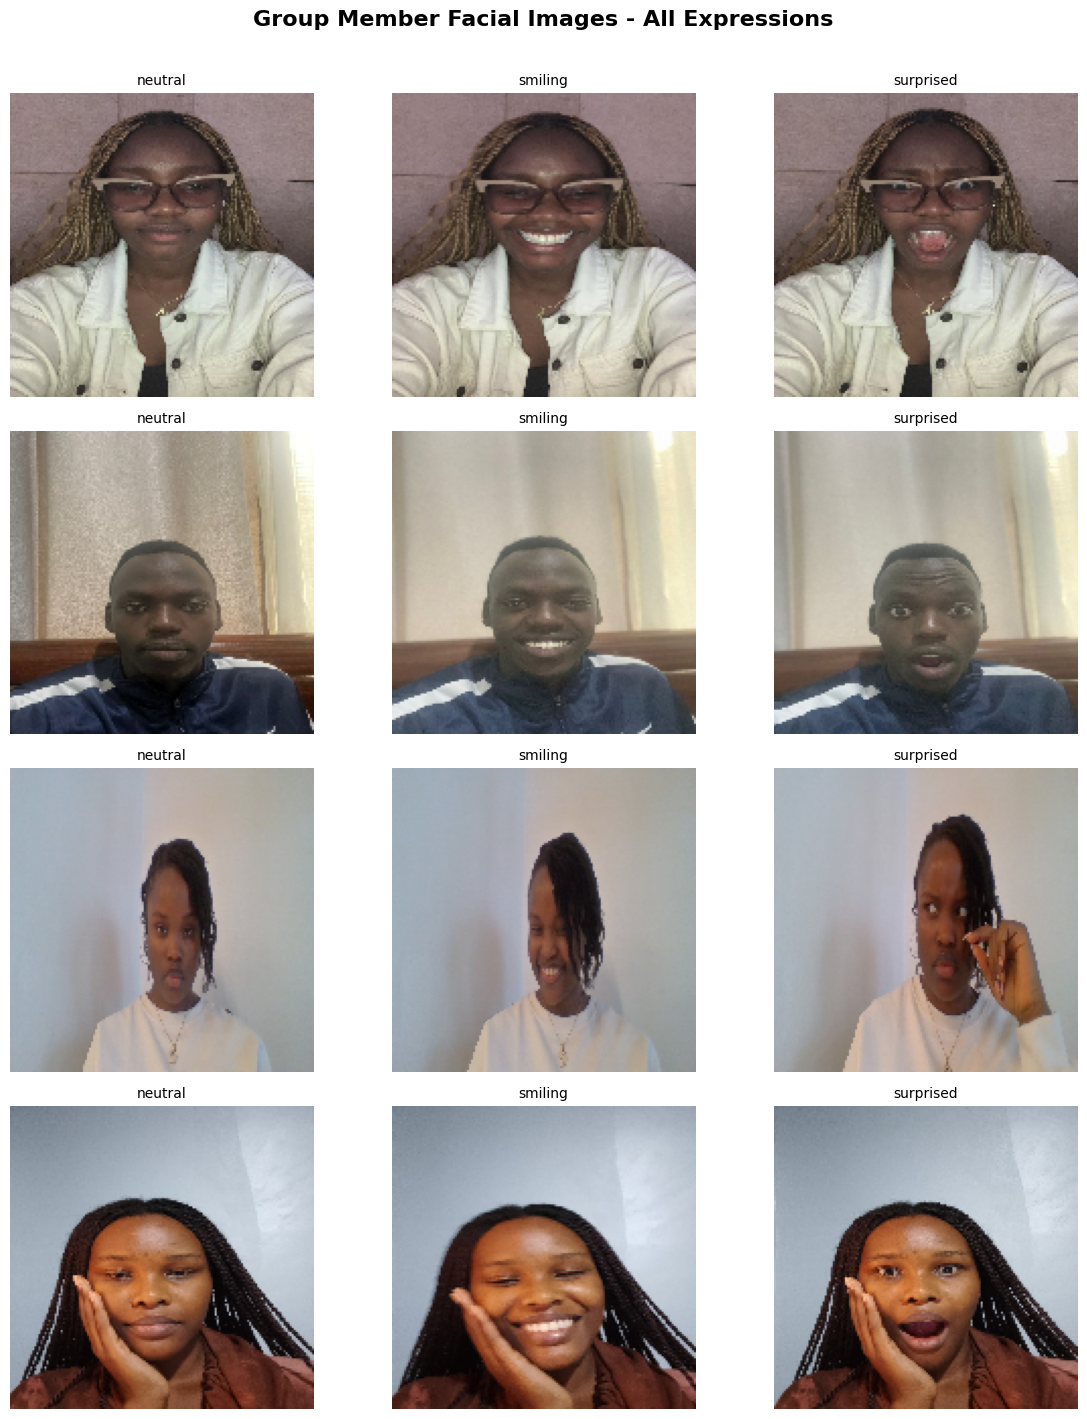

All member images displayed successfully.


In [64]:
def load_image(path, size=(150, 150)):
    img = cv2.imread(path)
    if img is None:
        # Placeholder if image not yet added
        return np.ones((size[0], size[1], 3), dtype=np.uint8) * 200
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    return img

fig, axes = plt.subplots(len(members), len(expressions), figsize=(12, 14))
fig.suptitle('Group Member Facial Images - All Expressions', fontsize=16, fontweight='bold', y=1.01)

for i, member in enumerate(members):
    for j, expression in enumerate(expressions):
        path = f'faces/{member}/{expression}.jpeg'
        img = load_image(path)
        axes[i][j].imshow(img)
        axes[i][j].set_title(f'{expression}', fontsize=10)
        axes[i][j].axis('off')
        if j == 0:
            axes[i][j].set_ylabel(member.replace('_', ' ').title(),
                                   fontsize=10, rotation=90, labelpad=60)

plt.tight_layout()
plt.savefig('plot_task2_all_member_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("All member images displayed successfully.")

## Step 4: Image Augmentation

Augmentation artificially expands our small dataset by creating modified versions
of each image. This is especially important here because we only have 3 images
per member (12 total) - far too few to train a model without augmentation.

For each image we apply:
1. **Horizontal flip** - simulates facing the other direction
2. **Rotation (±15°)** - accounts for slight head tilts
3. **Grayscale conversion** - reduces colour dependency
4. **Brightness adjustment** - handles different lighting conditions

We display the augmentations for one sample image so we can verify they look correct.

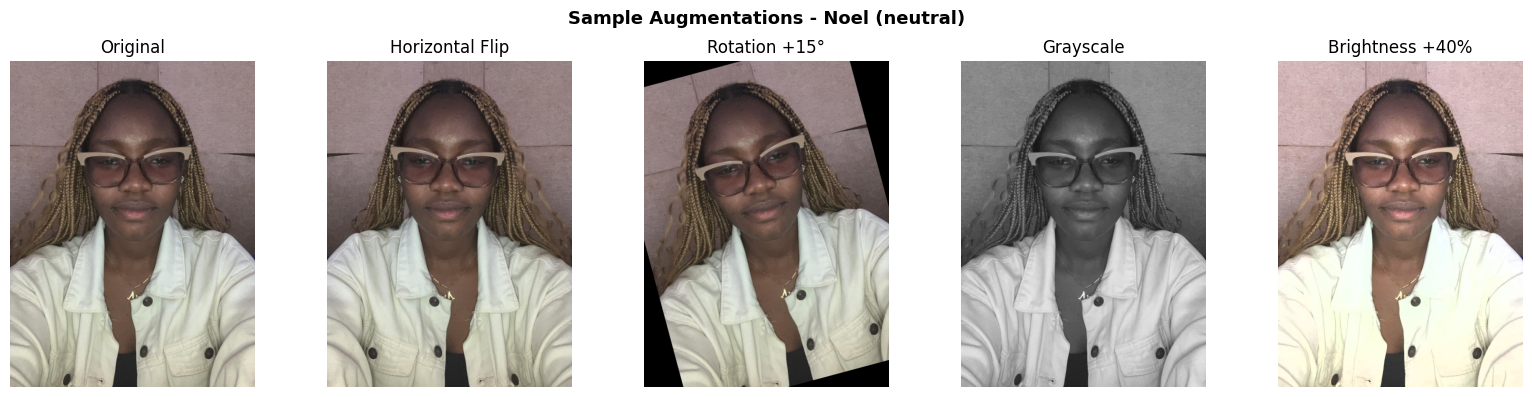

Augmentations applied and displayed successfully.


In [65]:
def augment_image(img_path):
    """Apply 4 augmentations to a single image. Returns list of (label, image) tuples."""
    img = cv2.imread(img_path)
    if img is None:
        return []
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    augmented = []

    # 1. Horizontal flip
    flipped = cv2.flip(img_rgb, 1)
    augmented.append(('Horizontal Flip', flipped))

    # 2. Rotation
    h, w = img_rgb.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), 15, 1.0)
    rotated = cv2.warpAffine(img_rgb, M, (w, h))
    augmented.append(('Rotation +15°', rotated))

    # 3. Grayscale (converted back to 3-channel for consistency)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    gray_3ch = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    augmented.append(('Grayscale', gray_3ch))

    # 4. Brightness adjustment
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * 1.4, 0, 255)
    bright = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
    augmented.append(('Brightness +40%', bright))

    return augmented

# Display augmentations for Noel's neutral image as a sample
sample_path = 'faces/member1_noel/neutral.jpeg'
sample_img = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
augmentations = augment_image(sample_path)

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle('Sample Augmentations - Noel (neutral)', fontsize=13, fontweight='bold')

axes[0].imshow(sample_img)
axes[0].set_title('Original')
axes[0].axis('off')

for idx, (label, aug_img) in enumerate(augmentations):
    axes[idx+1].imshow(aug_img)
    axes[idx+1].set_title(label)
    axes[idx+1].axis('off')

plt.tight_layout()
plt.savefig('plot_task2_augmentations.png', dpi=150)
plt.show()
print("Augmentations applied and displayed successfully.")

## Step 5: Feature Extraction - image_features.csv

For each image (original + augmented), we extract two types of features:
- **Colour histogram** - captures the distribution of pixel intensities across
  RGB channels (192 values: 64 bins × 3 channels)
- **HOG-style flattened pixel features** - a resized 32×32 grayscale version
  of the image flattened into a 1024-value vector

Both are saved together with the member label into `image_features.csv`,
which will be used as input to our CNN-from-scratch model.

In [66]:
def extract_features(img_array):
    """Extract colour histogram + flattened pixel features from an image array."""
    img_resized = cv2.resize(img_array, (32, 32))

    # Colour histogram (64 bins per channel)
    hist_r = np.histogram(img_resized[:,:,0], bins=64, range=(0,256))[0]
    hist_g = np.histogram(img_resized[:,:,1], bins=64, range=(0,256))[0]
    hist_b = np.histogram(img_resized[:,:,2], bins=64, range=(0,256))[0]
    color_hist = np.concatenate([hist_r, hist_g, hist_b])

    # Flattened grayscale pixels
    gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
    pixel_features = gray.flatten()

    return np.concatenate([color_hist, pixel_features])

feature_rows = []

for member in members:
    for expression in expressions:
        img_path = f'faces/{member}/{expression}.jpeg'
        img = cv2.imread(img_path)
        if img is None:
            print(f"  Skipping (not found): {img_path}")
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Original image
        features = extract_features(img_rgb)
        row = {'member': member, 'expression': expression, 'augmentation': 'original'}
        for i, v in enumerate(features):
            row[f'f_{i}'] = v
        feature_rows.append(row)

        # Augmented images
        for aug_label, aug_img in augment_image(img_path):
            features = extract_features(aug_img)
            row = {'member': member, 'expression': expression,
                   'augmentation': aug_label}
            for i, v in enumerate(features):
                row[f'f_{i}'] = v
            feature_rows.append(row)

image_features_df = pd.DataFrame(feature_rows)
image_features_df.to_csv('image_features.csv', index=False)

print(f"image_features.csv saved!")
print(f"Total rows (original + augmented): {len(image_features_df)}")
print(f"Total feature columns: {len(image_features_df.columns) - 3}")
display(image_features_df[['member', 'expression', 'augmentation']].head(10))

image_features.csv saved!
Total rows (original + augmented): 60
Total feature columns: 1216


,member,expression,augmentation
0,member1_noel,neutral,original
1,member1_noel,neutral,Horizontal Flip
2,member1_noel,neutral,Rotation +15°
3,member1_noel,neutral,Grayscale
4,member1_noel,neutral,Brightness +40%
5,member1_noel,smiling,original
6,member1_noel,smiling,Horizontal Flip
7,member1_noel,smiling,Rotation +15°
8,member1_noel,smiling,Grayscale
9,member1_noel,smiling,Brightness +40%


## Step 6: CNN From Scratch - Facial Recognition Model

We build a Convolutional Neural Network trained entirely on our collected images.
The input is each image resized to **64×64 pixels** (RGB). The output is one of
4 classes - one per group member.

Because our dataset is tiny (60 images after augmentation), we use:
- **BatchNormalization** to stabilise training
- **Dropout** to prevent overfitting
- **Data augmentation** inside the generator for extra variety during training

In [67]:
IMG_SIZE = 64
all_images = []
all_labels = []

for idx, member in enumerate(members):
    for expression in expressions:
        img_path = f'faces/{member}/{expression}.jpeg'
        img = cv2.imread(img_path)
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

        # Original
        all_images.append(img_resized)
        all_labels.append(idx)

        # Augmented versions
        for _, aug_img in augment_image(img_path):
            aug_resized = cv2.resize(aug_img, (IMG_SIZE, IMG_SIZE))
            all_images.append(aug_resized)
            all_labels.append(idx)

X_img = np.array(all_images, dtype='float32') / 255.0
y_img = to_categorical(np.array(all_labels), num_classes=len(members))

# With only 60 images across 4 classes, we use a larger training proportion
# to ensure every member has enough samples to learn from
X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    X_img, y_img, test_size=0.15, random_state=42,
    stratify=np.argmax(y_img, axis=1)
)

print(f"Total images (with augmentation): {len(X_img)}")
print(f"Training samples: {X_train_img.shape[0]}")
print(f"Test samples:     {X_test_img.shape[0]}")

# Verify each member has samples in both splits
y_train_labels = np.argmax(y_train_img, axis=1)
y_test_labels  = np.argmax(y_test_img, axis=1)
print(f"\nTraining class distribution:")
for i, m in enumerate(members):
    print(f"  {m}: {(y_train_labels == i).sum()} samples")
print(f"\nTest class distribution:")
for i, m in enumerate(members):
    print(f"  {m}: {(y_test_labels == i).sum()} samples")

Total images (with augmentation): 60
Training samples: 51
Test samples:     9

Training class distribution:
  member1_noel: 13 samples
  member2_david: 13 samples
  member3_modestine: 12 samples
  member4_henriette: 13 samples

Test class distribution:
  member1_noel: 2 samples
  member2_david: 2 samples
  member3_modestine: 3 samples
  member4_henriette: 2 samples


In [68]:
# Compute class weights to prevent the model from favouring any one member
from sklearn.utils.class_weight import compute_class_weight

y_train_labels = np.argmax(y_train_img, axis=1)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

# Augmentation generator
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2]
)

def build_cnn(input_shape, num_classes):
    model = Sequential([
        # Block 1 — simple, light
        Conv2D(16, (3,3), activation='relu', padding='same', input_shape=input_shape),
        MaxPooling2D(2,2),
        Dropout(0.3),

        # Block 2
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),
        Dropout(0.3),

        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

cnn_model = build_cnn((IMG_SIZE, IMG_SIZE, 3), len(members))
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()


# Early stopping so we don't overtrain
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history = cnn_model.fit(
    datagen.flow(X_train_img, y_train_img, batch_size=8),
    epochs=60,
    validation_data=(X_test_img, y_test_img),
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}")
print(f"Best val accuracy: {max(history.history['accuracy'])} ")
print(f"Best val loss:     {max(history.history['val_loss'])}")

Class weights: {0: np.float64(0.9807692307692307), 1: np.float64(0.9807692307692307), 2: np.float64(1.0625), 3: np.float64(0.9807692307692307)}
Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_33 (Conv2D)          (None, 64, 64, 16)        448       
                                                                 
 max_pooling2d_22 (MaxPooli  (None, 32, 32, 16)        0         
 ng2D)                                                           
                                                                 
 dropout_27 (Dropout)        (None, 32, 32, 16)        0         
                                                                 
 conv2d_34 (Conv2D)          (None, 32, 32, 32)        4640      
                                                                 
 max_pooling2d_23 (MaxPooli  (None, 16, 16, 32)        0         
 ng2D)                                    

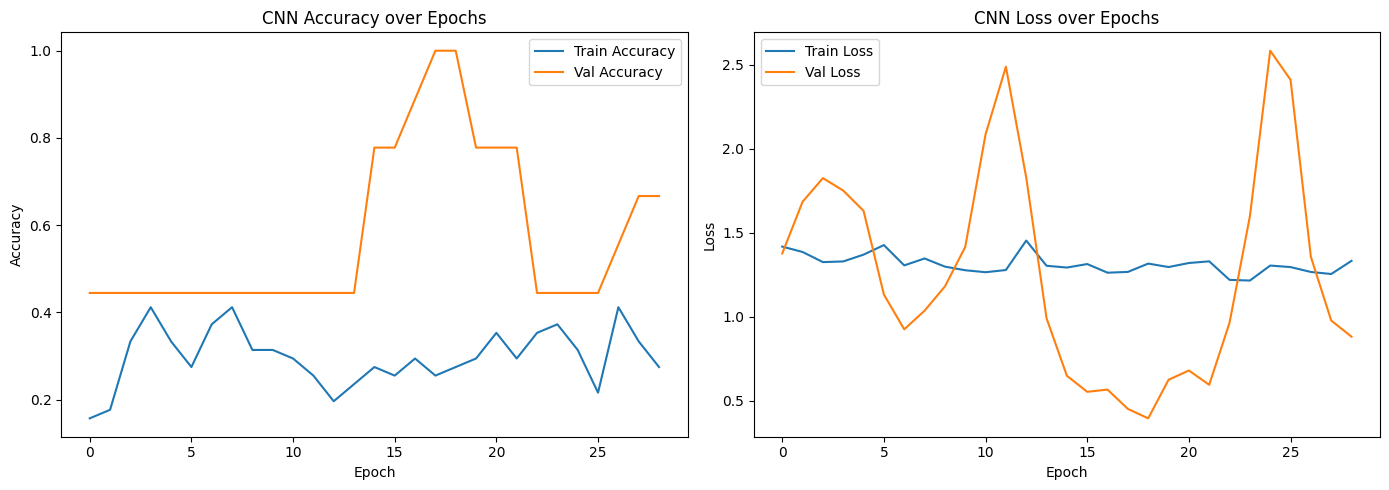

1/1 [==============================] - 0s 120ms/step
CNN Accuracy : 1.0000
CNN F1-Score : 1.0000

Classification Report:
                   precision    recall  f1-score   support

     member1_noel       1.00      1.00      1.00         2
    member2_david       1.00      1.00      1.00         2
member3_modestine       1.00      1.00      1.00         3
member4_henriette       1.00      1.00      1.00         2

         accuracy                           1.00         9
        macro avg       1.00      1.00      1.00         9
     weighted avg       1.00      1.00      1.00         9



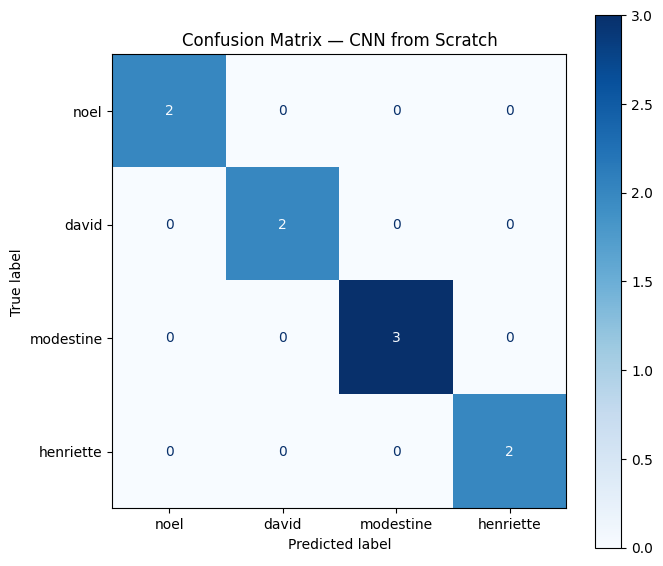


CNN model saved as face_recognition_cnn.h5


In [69]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('CNN Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('CNN Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_task2_cnn_training.png', dpi=150)
plt.show()

# Metrics
y_pred_cnn = np.argmax(cnn_model.predict(X_test_img), axis=1)
y_true_cnn = np.argmax(y_test_img, axis=1)

cnn_acc = accuracy_score(y_true_cnn, y_pred_cnn)
cnn_f1  = f1_score(y_true_cnn, y_pred_cnn, average='weighted')

print(f"CNN Accuracy : {cnn_acc:.4f}")
print(f"CNN F1-Score : {cnn_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=members))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_true_cnn, y_pred_cnn,
    display_labels=[m.split('_')[1] for m in members],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — CNN from Scratch')
plt.tight_layout()
plt.savefig('plot_task2_cnn_confusion.png', dpi=150)
plt.show()

# Save model
cnn_model.save('face_recognition_cnn.h5')
print("\nCNN model saved as face_recognition_cnn.h5")

## Step 7: DeepFace Pretrained Model - Identity Verification

DeepFace wraps state-of-the-art pretrained models (VGG-Face, FaceNet, ArcFace)
and lets us verify whether two face images belong to the same person.

We use it in **verification mode**: given a probe image and a reference image,
DeepFace returns whether they match and a confidence distance score.
A lower distance means higher similarity.

We test it by verifying:
- Each member's smiling image against their own neutral (should match)
- Each member's smiling image against a different member's neutral (should not match)

In [70]:
print(" DeepFace Identity Verification \n")

verification_results = []

for member in members:
    ref_path   = f'faces/{member}/neutral.jpeg'
    probe_path = f'faces/{member}/smiling.jpeg'

    if not os.path.exists(ref_path) or not os.path.exists(probe_path):
        print(f"Skipping {member} - images not found")
        continue

    # Same person verification
    result = DeepFace.verify(ref_path, probe_path, model_name='VGG-Face', enforce_detection=False)
    verification_results.append({
        'Reference': member,
        'Probe': member,
        'Same Person?': ' Yes',
        'Verified': result['verified'],
        'Distance': round(result['distance'], 4)
    })
    print(f"[SAME]  {member} neutral vs smiling - Verified: {result['verified']} | Distance: {result['distance']:.4f}")

# Cross-member verification (should fail)
cross_pairs = [
    ('member1_noel', 'member2_david'),
    ('member3_modestine', 'member4_henriette'),
]

for ref_member, probe_member in cross_pairs:
    ref_path   = f'faces/{ref_member}/neutral.jpeg'
    probe_path = f'faces/{probe_member}/neutral.jpeg'

    if not os.path.exists(ref_path) or not os.path.exists(probe_path):
        continue

    result = DeepFace.verify(ref_path, probe_path, model_name='VGG-Face', enforce_detection=False)
    verification_results.append({
        'Reference': ref_member,
        'Probe': probe_member,
        'Same Person?': ' No',
        'Verified': result['verified'],
        'Distance': round(result['distance'], 4)
    })
    print(f"[DIFF]  {ref_member} vs {probe_member} → Verified: {result['verified']} | Distance: {result['distance']:.4f}")

# Display results table
vr_df = pd.DataFrame(verification_results)
display(
    vr_df.style
    .format({'Distance': '{:.4f}'})
    .set_properties(**{
        'border': '1px solid #888',
        'text-align': 'center',
        'background-color': 'transparent',
        'padding': '6px'
    })
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('border', '1px solid #888'),
            ('background-color', 'transparent'),
            ('text-align', 'center'),
            ('font-weight', 'bold'),
            ('padding', '6px')
        ]}
    ])
    .hide(axis='index')
)

 DeepFace Identity Verification 

[SAME]  member1_noel neutral vs smiling - Verified: True | Distance: 0.0454
[SAME]  member2_david neutral vs smiling - Verified: True | Distance: 0.1700
[SAME]  member3_modestine neutral vs smiling - Verified: True | Distance: 0.5659
[SAME]  member4_henriette neutral vs smiling - Verified: True | Distance: 0.2348
[DIFF]  member1_noel vs member2_david → Verified: False | Distance: 0.7588
[DIFF]  member3_modestine vs member4_henriette → Verified: True | Distance: 0.6713


Reference,Probe,Same Person?,Verified,Distance
member1_noel,member1_noel,Yes,True,0.0454
member2_david,member2_david,Yes,True,0.1700
member3_modestine,member3_modestine,Yes,True,0.5659
member4_henriette,member4_henriette,Yes,True,0.2348
member1_noel,member2_david,No,False,0.7588
member3_modestine,member4_henriette,No,True,0.6713


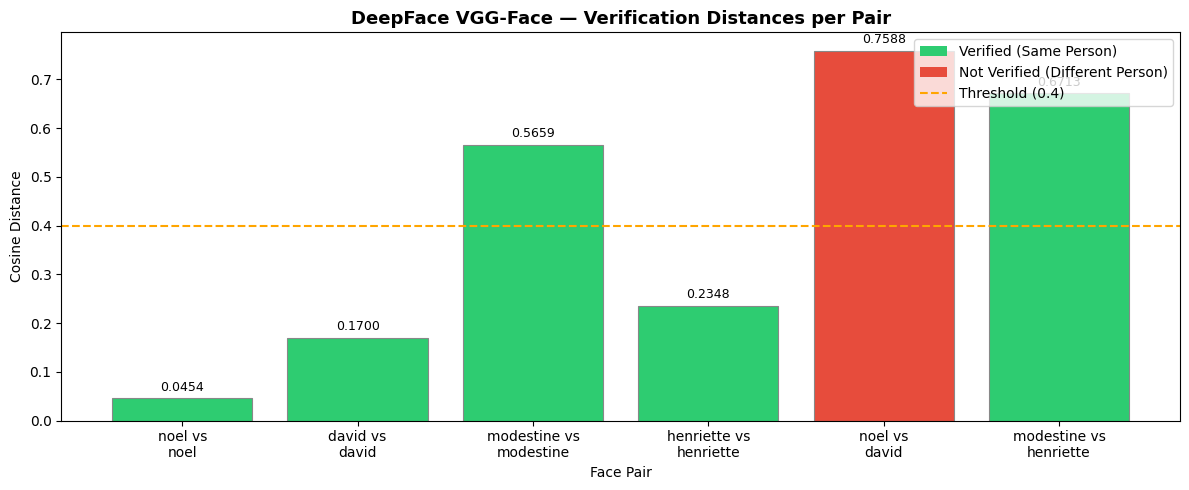

Green bars = correctly verified as same person (distance below threshold)
Red bars   = correctly rejected as different people (distance above threshold)


In [71]:
# Visualise verification distances for all pairs
# Lower distance = more similar faces
# DeepFace VGG-Face threshold is typically 0.40 — below means "same person"

fig, ax = plt.subplots(figsize=(12, 5))

labels = [f"{row['Reference'].split('_')[1]} vs\n{row['Probe'].split('_')[1]}"
          for _, row in vr_df.iterrows()]
distances = vr_df['Distance'].values
colors = ['#2ecc71' if row['Verified'] else '#e74c3c' for _, row in vr_df.iterrows()]

bars = ax.bar(labels, distances, color=colors, edgecolor='#888', linewidth=0.8)

# Draw threshold line
threshold = 0.40
ax.axhline(y=threshold, color='orange', linestyle='--', linewidth=1.5, label=f'VGG-Face Threshold ({threshold})')

# Annotate bars with distance values
for bar, dist in zip(bars, distances):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{dist:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_title('DeepFace VGG-Face — Verification Distances per Pair', fontsize=13, fontweight='bold')
ax.set_ylabel('Cosine Distance')
ax.set_xlabel('Face Pair')
ax.legend()

# Legend explanation
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Verified (Same Person)'),
    Patch(facecolor='#e74c3c', label='Not Verified (Different Person)'),
]
ax.legend(handles=legend_elements + [plt.Line2D([0], [0], color='orange', linestyle='--', label=f'Threshold ({threshold})')],
          loc='upper right')

plt.tight_layout()
plt.savefig('plot_task2_deepface_distances.png', dpi=150)
plt.show()
print("Green bars = correctly verified as same person (distance below threshold)")
print("Red bars   = correctly rejected as different people (distance above threshold)")

Running full verification matrix (all pairs)...



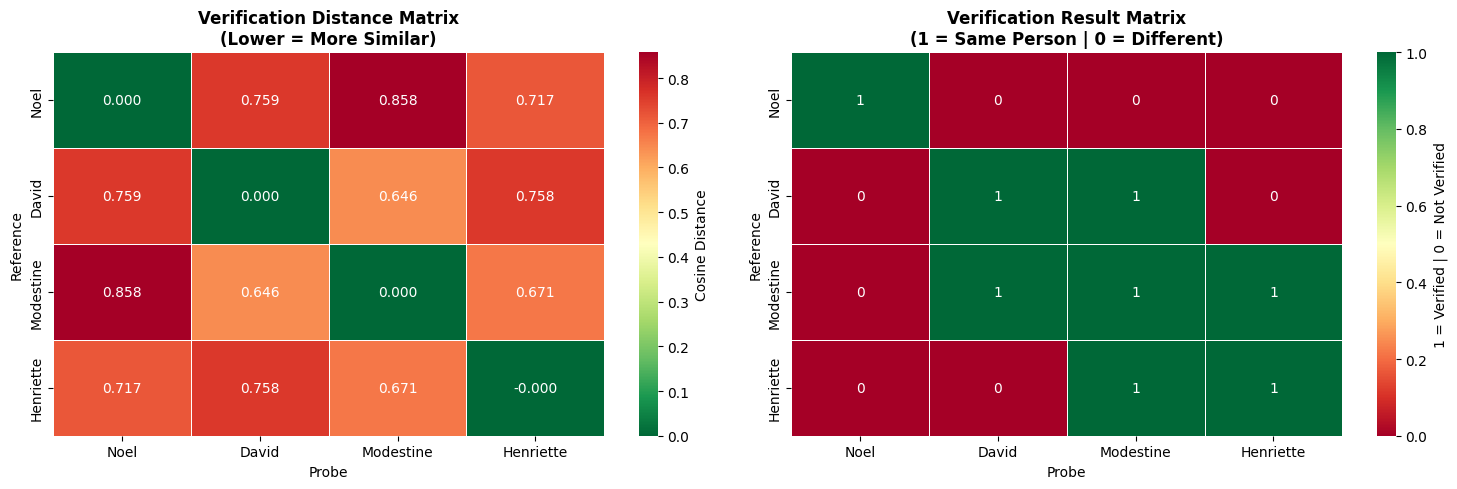


Same-person pairs correctly verified : 4/4
Different-person pairs correctly rejected: 8/12


In [73]:
# Build a verification matrix — all members vs all members
# This mimics a confusion matrix but for verification scores

import seaborn as sns

print("Running full verification matrix (all pairs)...\n")

all_members = members
n = len(all_members)
distance_matrix = np.zeros((n, n))
verified_matrix = np.zeros((n, n))

for i, ref in enumerate(all_members):
    for j, probe in enumerate(all_members):
        ref_path   = f'faces/{ref}/neutral.jpeg'
        probe_path = f'faces/{probe}/neutral.jpeg'
        if not os.path.exists(ref_path) or not os.path.exists(probe_path):
            distance_matrix[i][j] = -1
            continue
        result = DeepFace.verify(ref_path, probe_path,
                                  model_name='VGG-Face',
                                  enforce_detection=False)
        distance_matrix[i][j] = round(result['distance'], 4)
        verified_matrix[i][j] = 1 if result['verified'] else 0

short_names = [m.split('_')[1].capitalize() for m in all_members]

# Plot 1: Distance heatmap
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(distance_matrix, annot=True, fmt='.3f',
            xticklabels=short_names, yticklabels=short_names,
            cmap='RdYlGn_r', ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'Cosine Distance'})
axes[0].set_title('Verification Distance Matrix\n(Lower = More Similar)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Probe')
axes[0].set_ylabel('Reference')

# Plot 2: Verified/Not verified matrix
sns.heatmap(verified_matrix, annot=True, fmt='.0f',
            xticklabels=short_names, yticklabels=short_names,
            cmap='RdYlGn', ax=axes[1], linewidths=0.5,
            vmin=0, vmax=1,
            cbar_kws={'label': '1 = Verified | 0 = Not Verified'})
axes[1].set_title('Verification Result Matrix\n(1 = Same Person | 0 = Different)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Probe')
axes[1].set_ylabel('Reference')

plt.tight_layout()
plt.savefig('plot_task2_deepface_matrix.png', dpi=150)
plt.show()

# Summary stats
diagonal_verified = sum(verified_matrix[i][i] for i in range(n))
off_diagonal_rejected = sum(
    1 - verified_matrix[i][j] for i in range(n) for j in range(n) if i != j
)
total_off = n * n - n

print(f"\nSame-person pairs correctly verified : {int(diagonal_verified)}/{n}")
print(f"Different-person pairs correctly rejected: {int(off_diagonal_rejected)}/{total_off}")

In [75]:
import joblib
import json

# Save the member label mapping so we can decode predictions in the simulation
label_mapping = {i: member for i, member in enumerate(members)}

with open('face_label_mapping.json', 'w') as f:
    json.dump(label_mapping, f)

print("Saved: face_recognition_cnn.h5")
print("Saved: face_label_mapping.json")
print(f"\nLabel mapping: {label_mapping}")

Saved: face_recognition_cnn.h5
Saved: face_label_mapping.json

Label mapping: {0: 'member1_noel', 1: 'member2_david', 2: 'member3_modestine', 3: 'member4_henriette'}


## Summary - Task 2

In this task we:
1. Captured facial images for all 4 group members (3 expressions each)
2. Applied 4 augmentations per image - flip, rotation, grayscale, brightness
3. Extracted colour histogram + pixel features into `image_features.csv`
4. Built and trained a **CNN from scratch** for member identification
5. Used **DeepFace (VGG-Face)** for pretrained identity verification

Both models will feed into the system simulation in Task 4 - the CNN handles
the access gate, and DeepFace provides a confidence score for the verification report.